# Case 1: Retaining wall

## Introduction

This notebook demonstrates the use of reliability methods from the Deltares Probabilistic Library on a realistic geotechnical benchmark: the stability of a gravity retaining wall. It is adapted from the guidelines for the application of the 2nd generation of Eurocode 7: *"Reliability-based verification of limit states for geotechnical structures"* (2024). Because the limit state function can be expressed in closed form, this example provides a transparent and verifiable starting point for exploring the library.

The retaining wall is assessed against three failure mechanisms:

- **Sliding** along the base  
- **Bearing capacity** failure of the foundation soil  
- **Overturning** about the toe  

System failure occurs when **any one** mechanism is critical. The system limit state function $g_\text{sys}$ is therefore taken as the minimum over the three individual values.

The model involves four stochastic variables:

| Variable | Description | Unit | Distribution |
|----------|-------------|------|-------------|
| $\gamma_1$ | Unit weight of the backfill soil | kN/m³ | Normal |
| $\gamma_2$ | Unit weight of the foundation soil | kN/m³ | Normal |
| $\phi_1$ | Friction angle of the backfill soil | ° | Normal (truncated) |
| $\phi_2$ | Friction angle of the foundation soil | ° | Normal |

Six reliability methods are applied and compared: **FORM**, **Crude Monte Carlo**, **Directional Sampling**, **Importance Sampling**, **Adaptive Importance Sampling**, and **Subset Simulation**.

<img src="../tutorials/case_1_retaining_wall.png" alt="Retaining wall geometry — Source: Ching &amp; Hsieh (2011)" width="420"/>

*Source: Ching & Hsieh (2011)*

In [1]:
from probabilistic_library import ReliabilityProject, DistributionType, ReliabilityMethod, StartMethod, StandardNormal, GradientType, SampleMethod
import numpy as np

## Model definition

The system limit state function is defined as:

$$g_\text{sys}(\mathbf{X}) = \min\bigl(g_1(\mathbf{X}),\; g_2(\mathbf{X}),\; g_3(\mathbf{X})\bigr)$$

where:

| Sub-function | Failure mode | Definition |
|---|---|---|
| $g_1$ | **Sliding** | Horizontal passive resistance − active force component |
| $g_2$ | **Bearing capacity** | Ultimate soil load capacity − applied vertical load |
| $g_3$ | **Overturning** | Resisting moment − overturning moment |

The sign convention is $g > 0$ (safe) and $g \leq 0$ (failure). System failure is triggered as soon as any one mechanism becomes critical.

The three sub-functions and their assembly into `LSF_retaining_wall` are defined below. The function arguments (`gamma_1`, `gamma_2`, `phi_1`, `phi_2`) must exactly match the variable names used in the project.

In [2]:
def g_1_sliding(Pa, delta_1, delta_2, theta, Ww, Wr):
    return (Pa*np.sin(delta_1+theta) + Ww + Wr)*np.tan(delta_2) - Pa*np.cos(delta_1+theta)

def g_2_bearing_capacity(qu, Lb, Ww, Wr, Pa, delta_1, theta):
    """
    Limit state function for bearing capacity

    Parameters

    qu : float
        Ultimate bearing capacity.

    Lb : float

    Ww : float
        Weight of the wall.

    Wr : float
        Weight of the wall

    Pa : float
        Active force

    delta_1 : float
        friction angle between the backfill and the back of the wall
    
    theta : float
        back angle of the retaining wall

    """
    return qu*Lb-(Ww + Wr + Pa*np.sin(delta_1+theta))

def g3_overturning(Mr, M0):
    """
    Limit state function for overturning

    Parameters
    ----------
    Mo : float
        Overturning moment.
    Mr : float
        Resisting moment.
    """
    return Mr - M0
    

In [3]:
def LSF_retaining_wall(gamma_1, gamma_2, phi_1, phi_2):
    """
    Function to calculate the reliability index
    :param gamma_1: Unit weight of the backfill soil
    :param gamma_2: Unit weight of the foundation soil
    :param phi_1: Friction angle ok the backfill
    :param phi_2: Friction angle of the foundation soil
    """

    H = 4 # Height of the wall in m
    B = 2.5 # Top width of the wall in m
    L = 3.5  # Bottom of the wall in m
    alpha_m = 5.0  # slope of the backfill soil in in deg
    gamma_Ww = 23.58  # unit weight of the retaining wall in kN/m3

    alpha = np.radians(alpha_m) # in rad

    t = np.arctan((L-B)/H)
    phi_1 = np.radians(phi_1)
    phi_2 = np.radians(phi_2)
    delta_1 = 2/3*phi_1
    delta_2 = 2/3*phi_2
    Ka = np.cos(phi_1-t)**2/(np.cos(t)**2*np.cos(delta_1+t)*(1+np.sqrt(np.sin(delta_1+phi_1)*np.sin(phi_1-alpha)/np.cos(delta_1+t)/np.cos(t-alpha)))**2)

    Pa = 0.5*Ka*gamma_1*H**2    
    
    Ww = gamma_Ww*B*H
    Wr = gamma_Ww*(L-B)*H/2
    
    beta = np.arctan(Pa*np.cos(delta_1+t)/(Pa*np.sin(delta_1+t) + Ww + Wr))
    
    Fg = (1-np.rad2deg(beta)/np.rad2deg(phi_2))**2
    Nq = np.exp(np.pi*np.tan(phi_2))*np.tan(np.pi/4+phi_2/2)**2
    Ng = 2*(Nq+1)*np.tan(phi_2)
    
    Mr = Ww*B/2 + Wr*(B+1/3*(L-B)) + Pa*np.sin(delta_1+t)*(B+2/3*(L-B))
    Mo = Pa*np.cos(delta_1+t)*H/3

    xb = (Mr-Mo)/(Ww + Wr + Pa*np.sin(delta_1+t))
    
    eL = np.abs(xb-L/2)
    Lb = L-2*eL
    qu = 0.5*gamma_2*Lb*Ng*Fg

    g1 = g_1_sliding(Pa, delta_1, delta_2, t, Ww, Wr)
    g2 = g_2_bearing_capacity(qu, Lb, Ww, Wr, Pa, delta_1, t)
    g3 = g3_overturning(Mr, Mo)
    g_syst = np.min(np.array([g1, g2, g3]), axis=0)
    return g_syst


## Setting up the project

A `ReliabilityProject` is the central object that ties together the model, the stochastic variables, the numerical settings, and the results. Here we create a new project and assign `LSF_retaining_wall` as the model to evaluate.

In [4]:
project = ReliabilityProject()
project.model = LSF_retaining_wall

## Stochastic variables

Each argument of `LSF_retaining_wall` is registered as a stochastic variable. For each variable we specify:

- `distribution` — the marginal distribution type  
- `mean` — the mean value  
- `variation` — the **coefficient of variation** (CoV = σ/μ), which the library uses to derive the standard deviation  

All four variables follow a **Normal** distribution. The friction angle $\phi_1$ is additionally **truncated** to the interval [5°, 45°] to prevent physically meaningless values during sampling.

In [5]:
project.variables["phi_1"].distribution = DistributionType.normal
project.variables["phi_1"].mean = 35
project.variables["phi_1"].variation = 0.1
project.variables["phi_1"].truncated = True
project.variables["phi_1"].minimum = 5
project.variables["phi_1"].maximum = 45 


project.variables["phi_2"].distribution = DistributionType.normal
project.variables["phi_2"].mean = 35
project.variables["phi_2"].variation = 0.1
 
project.variables["gamma_1"].distribution = DistributionType.normal
project.variables["gamma_1"].mean = 19
project.variables["gamma_1"].variation = 0.1

project.variables["gamma_2"].distribution = DistributionType.normal
project.variables["gamma_2"].mean = 17
project.variables["gamma_2"].variation = 0.1


## Reliability analysis

We now run six reliability methods. Each method estimates the **reliability index** $\beta$ and the corresponding **probability of failure** $P_f = \Phi(-\beta)$, where $\Phi$ is the standard normal CDF.

### 1 · FORM — First Order Reliability Method

FORM approximates the limit state surface by a hyperplane (first-order Taylor expansion) at the **design point** — the most probable failure point in standard normal space. It is computationally efficient and, as a by-product, provides **α-factors** that quantify each variable's relative contribution to the probability of failure.

Three settings control the iteration:

- **`relaxation_factor`** — a damping coefficient (between 0 and 1) that scales the step size in the iHLRF algorithm. Smaller values improve stability for strongly non-linear problems at the cost of more iterations.  
- **`maximum_iterations`** — hard upper limit on the number of iterations.  
- **`variation_coefficient`** — convergence threshold: iteration stops when the normalised step size falls below this value.

In [14]:
project.settings.reliability_method = ReliabilityMethod.form

project.settings.relaxation_factor = 0.15
project.settings.maximum_iterations = 100
project.settings.variation_coefficient = 0.02

project.run()

The helper function `read_results` below extracts the key outputs from the design point and returns them in a dictionary for later comparison. It is defined once here and reused after every subsequent method run.

In [ ]:
def read_results(dp):

    beta = dp.reliability_index

    print(f"Beta = {beta}")

    pf = StandardNormal.get_q_from_u(beta)
    print(f"Probability of failure = {pf}")

    for alpha in dp.alphas:
        print(f"{alpha.variable.name}: alpha = {alpha.alpha}, x = {alpha.x}")

    if dp.is_converged:
        print(f"Converged (convergence = {dp.convergence} < {project.settings.epsilon_beta})")
    else:
        print(f"Not converged (convergence = {dp.convergence} > {project.settings.epsilon_beta})")
        
    print(f"Model runs = {dp.total_model_runs}")
    return dict(dp=dp, beta=beta, pf=pf, alphas=dp.alphas, converged=dp.is_converged, convergence=dp.convergence, model_runs=dp.total_model_runs)

read_results(project.design_point)

Beta = 2.9263733572015203
Probability of failure = 0.0017146954960667192
gamma_1: alpha = -0.1549273133163195, x = 19.86141280778421
gamma_2: alpha = 0.14105825853061282, x = 16.29825847971871
phi_1: alpha = 0.24652517187546255, x = 32.46928593576917
phi_2: alpha = 0.9462163784889117, x = 25.308561599448186
Converged (convergence = 0.008532246341729577 < 0.02)
Model runs = 0


{'dp': <probabilistic_library.reliability.DesignPoint at 0x240edf32780>,
 'beta': 2.9263733572015203,
 'pf': 0.0017146954960667192,
 'alphas': <probabilistic_library.utils.FrozenList at 0x240edfb72f0>,
 'converged': True,
 'convergence': 0.008532246341729577,
 'model_runs': 0}

In [16]:
res_form =  read_results(project.design_point)

Beta = 2.9263733572015203
Probability of failure = 0.0017146954960667192
gamma_1: alpha = -0.1549273133163195, x = 19.86141280778421
gamma_2: alpha = 0.14105825853061282, x = 16.29825847971871
phi_1: alpha = 0.24652517187546255, x = 32.46928593576917
phi_2: alpha = 0.9462163784889117, x = 25.308561599448186
Converged (convergence = 0.008532246341729577 < 0.02)
Model runs = 0


No convergence data were saved, run again with settings.save_convergence = True


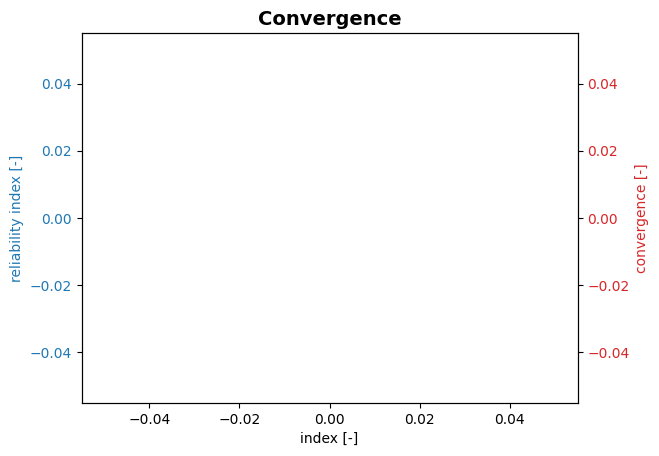

In [17]:
project.design_point.plot_convergence()

### 2 · Crude Monte Carlo Simulation

Crude Monte Carlo (CMC) estimates $P_f$ by drawing independent samples from the joint distribution and counting the fraction that fall in the failure domain ($g \leq 0$). It is the most straightforward reference method, but requires large sample sizes for small failure probabilities.

The adaptive stopping rule runs until the CoV of the $P_f$ estimate drops below `variation_coefficient`, or the sample count reaches `maximum_samples`.

In [9]:
project.settings.reliability_method = ReliabilityMethod.crude_monte_carlo

project.settings.minimum_samples = 1000
project.settings.maximum_samples = 500000
project.settings.variation_coefficient = 0.02

project.run()  # takes 17 seconds

In [11]:
res_MC = read_results(project.design_point)

Beta = 2.906754233612549
Probability of failure = 0.0018260000000000207
gamma_1: alpha = -0.16177958086934452, x = 19.89348161504766
gamma_2: alpha = 0.160157304050106, x = 16.20858553329425
phi_1: alpha = 0.26018241482970117, x = 32.34738501789724
phi_2: alpha = 0.9383400855694731, x = 25.453665942959002
Not converged (convergence = 0.03306493992005365 > 0.02)
Model runs = 500000


No convergence data were saved, run again with settings.save_convergence = True


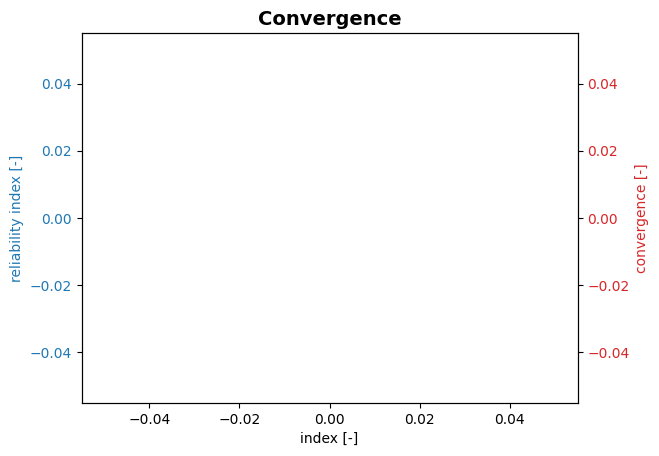

In [12]:
project.design_point.plot_convergence()

### 3 · Directional Sampling

Directional Sampling transforms the problem to hyperspherical coordinates and integrates analytically along random directions in standard normal space. For each direction, the probability contribution is computed exactly using the standard normal CDF, making it more efficient than crude Monte Carlo for smooth limit state functions. The settings `minimum_directions` and `maximum_directions` bound the number of random directions explored.

In [ ]:
project.settings.reliability_method = ReliabilityMethod.directional_sampling
project.settings.minimum_directions = 10000
project.settings.maximum_directions = 20000
project.settings.variation_coefficient = 0.02

project.run()


In [ ]:
res_DS = read_results(project.design_point)

### 4 · Importance Sampling

Importance Sampling (IS) concentrates sampling around the design point found by FORM by shifting the sampling density to that region. Because failure samples are generated much more frequently, it achieves Monte Carlo-level accuracy with far fewer model evaluations — typically one to two orders of magnitude fewer than crude Monte Carlo for moderate failure probabilities.

In [ ]:
project.settings.reliability_method = ReliabilityMethod.importance_sampling
project.settings.minimum_samples = 1000
project.settings.maximum_samples = 100000
project.settings.variation_coefficient = 0.02

project.run()

In [ ]:
res_IS = read_results(project.design_point)

### 5 · Adaptive Importance Sampling

Adaptive Importance Sampling (AIS) iteratively refines the sampling distribution based on accumulated results, without requiring a prior FORM run. The `minimum_variance_loops` / `maximum_variance_loops` settings control the adaptive phase, while `fraction_failed` sets the target fraction of failed samples per loop used to update the sampling density.

In [ ]:
project.settings.reliability_method = ReliabilityMethod.adaptive_importance_sampling
project.settings.minimum_samples = 10000
project.settings.maximum_samples = 100000
project.settings.minimum_variance_loops = 5
project.settings.maximum_variance_loops = 10
project.settings.fraction_failed = 0.5
project.settings.variation_coefficient = 0.02

project.run()

In [ ]:
res_AIS = read_results(project.design_point)

### 6 · Subset Simulation

Subset Simulation decomposes the failure probability into a product of conditional probabilities over a sequence of intermediate failure events of increasing severity. It is particularly well-suited for rare events ($P_f \lesssim 10^{-4}$) and does not require a prior FORM run. The `sample_method = SampleMethod.adaptive_conditional` selects the adaptive MCMC kernel used to generate samples conditional on each intermediate event.

In [ ]:
project.settings.reliability_method = ReliabilityMethod.subset_simulation
project.settings.minimum_samples = 1000
project.settings.maximum_samples = 50000
project.settings.variation_coefficient = 0.02
project.settings.sample_method = SampleMethod.adaptive_conditional

project.run()

In [ ]:
res_SS = read_results(project.design_point)

## Comparison of results

The table below summarises $\beta$ and the number of model evaluations for each method. All methods agree closely on $\beta \approx 2.9$, corresponding to $P_f \approx 1.8 \times 10^{-3}$.

| Method | β | Model evaluations |
|--------|---|-------------------|
| FORM | 2.93 | 95 |
| Crude Monte Carlo | 2.90 | 500,000 |
| Directional Sampling | 2.90 | 100,000 |
| Importance Sampling | 2.90 | 100,000 |
| Adaptive Importance Sampling | 2.92 | 41,136 |
| Subset Simulation | 2.91 | 45,000 |

**Key observations:**

- **FORM** is by far the most efficient method (< 100 evaluations). The close agreement with all simulation methods confirms that the limit state surface is well approximated as a hyperplane at the design point.
- **Importance Sampling** and **Adaptive Importance Sampling** reach Monte Carlo-level accuracy with roughly an order of magnitude fewer evaluations than crude Monte Carlo.
- **Subset Simulation** achieves similar efficiency to AIS without needing a prior FORM run, making it a robust choice when the shape of the limit state surface is unknown.
- According to Eurocode 7, $\beta \approx 2.9$ is associated with **Reliability Class RC1/RC2**, consistent with the design intent for this type of structure.